In [1]:
import operator

from typing import TypedDict, Annotated

from pydantic import BaseModel, Field

from langchain_ollama import ChatOllama

from langchain_core.messages import (
    SystemMessage,
    HumanMessage
)


from langgraph.graph import (
    StateGraph,
    START,
    END
)

In [2]:
llm = ChatOllama(
    model="llama3.2:3b",
    temperature=0.4,
    num_predict=320
)

In [3]:
class AnswerEvaluation(BaseModel):

    score: int = Field(
        ge=1,
        le=10,
        description="Quality score of the answer from 1 to 10."
    )

    feedback: str = Field(
        description="Short feedback explaining what should be improved."
    )

In [4]:
structured_evaluator = llm.with_structured_output(
    AnswerEvaluation
)

In [5]:
generator_llm = llm
optimizer_llm = llm

evaluator_llm = structured_evaluator

In [6]:
class AnswerState(TypedDict):

    question: str

    answer: str

    score: int

    feedback: str

    iteration: int

    max_iteration: int

    answer_history: Annotated[
        list[str],
        operator.add
    ]

    score_history: Annotated[
        list[int],
        operator.add
    ]

    feedback_history: Annotated[
        list[str],
        operator.add
    ]

In [7]:
def generate_answer(state: AnswerState):

    messages = [
        SystemMessage(
            content="""
You are a helpful assistant.

Answer the user's question clearly,
accurately, and concisely.
"""
        ),

        HumanMessage(
            content=state["question"]
        )
    ]

    response = generator_llm.invoke(messages)

    print("\nQuestion:\n")
    print(state["question"])

    print(f"\nIteration {state['iteration']}")
    print("\n" + "-" * 50)

    print("\nAnswer generated\n")
    print(response.content)

    return {
        "answer": response.content,

        "answer_history": [
            response.content
        ]
    }

In [8]:
def evaluate_answer(state: AnswerState):

    messages = [
        SystemMessage(
            content="""
You are a strict answer evaluator.

Evaluate the answer based on:

1. Accuracy
2. Relevance
3. Completeness
4. Clarity

Give a score from 1 to 10.

1-4 = Poor
5-7 = Needs improvement
8-10 = Good

Also provide short feedback explaining
how the answer can be improved.
"""
        ),

        HumanMessage(
            content=f"""
Question:
{state["question"]}

Answer:
{state["answer"]}
"""
        )
    ]

    result = evaluator_llm.invoke(messages)

    print(f"\nScore: {result.score}")
    print(f"\nFeedback: {result.feedback}")

    return {
        "score": result.score,

        "feedback": result.feedback,

        "score_history": [
            result.score
        ],

        "feedback_history": [
            result.feedback
        ]
    }

In [9]:
def improve_answer(state: AnswerState):

    messages = [
        SystemMessage(
            content="""
Improve the answer using the evaluator feedback.

Keep useful information.
Fix weaknesses.
Add missing important information.
Return only the improved answer.
"""
        ),

        HumanMessage(
            content=f"""
Question:
{state["question"]}

Current Answer:
{state["answer"]}

Feedback:
{state["feedback"]}
"""
        )
    ]

    response = optimizer_llm.invoke(messages)

    new_iteration = state["iteration"] + 1

    print(f"\n\nIteration {new_iteration}")
    print("\n" + "-" * 50)

    print("\nAnswer improved\n")
    print(response.content)

    return {
        "answer": response.content,

        "iteration": new_iteration,

        "answer_history": [
            response.content
        ]
    }

In [10]:
def route_evaluation(state: AnswerState):

    if state["score"] >= 9.5:

        print("\n\nFinal Answer")
        print("\n" + "-" * 50 + "\n")
        print(state["answer"])

        return "approved"

    if state["iteration"] >= state["max_iteration"]:

        print("\n\nFinal Answer")
        print("\n" + "-" * 50 + "\n")
        print(state["answer"])

        return "approved"

    return "needs_improvement"

In [11]:
graph = StateGraph(AnswerState)

graph.add_node(
    "generate",
    generate_answer
)

graph.add_node(
    "evaluate",
    evaluate_answer
)

graph.add_node(
    "improve",
    improve_answer
)

In [12]:
graph.add_edge(
    START,
    "generate"
)

graph.add_edge(
    "generate",
    "evaluate"
)

graph.add_conditional_edges(
    "evaluate",
    route_evaluation,
    {
        "approved": END,
        "needs_improvement": "improve"
    }
)

graph.add_edge(
    "improve",
    "evaluate"
)

In [13]:
workflow = graph.compile()

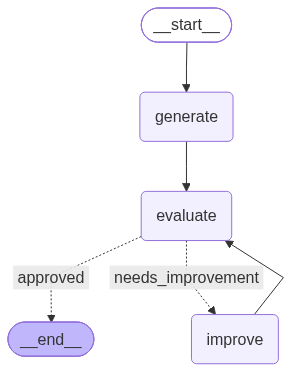

In [14]:
workflow

In [15]:
initial_state = {
    "question": "Explain the benefits of using electric vehicles.",

    "iteration": 1,

    "max_iteration": 5,

    "answer_history": [],

    "score_history": [],

    "feedback_history": []
}

In [16]:
result = workflow.invoke(
    initial_state
)


Question:

Explain the benefits of using electric vehicles.

Iteration 1

--------------------------------------------------

Answer generated

Electric vehicles (EVs) offer several benefits, including:

1. **Environmental Benefits**: EVs produce zero tailpipe emissions, reducing greenhouse gas emissions and air pollution in urban areas.
2. **Lower Operating Costs**: EVs are generally cheaper to run, with lower fuel costs (electricity is often less expensive than gasoline) and lower maintenance costs (fewer moving parts means less wear and tear).
3. **Improved Performance**: EVs have excellent acceleration and quiet operation, making for a smoother and more enjoyable driving experience.
4. **Government Incentives**: Many governments offer incentives, such as tax credits or rebates, to encourage the adoption of EVs.
5. **Reduced Dependence on Fossil Fuels**: EVs are powered by electricity, which can be generated from a variety of sources, including renewable energy, reducing our depend